# Playlist Theme Boundary Guard: phone-snapshot counterfactual

## Answer first

The current hard playlist policy is rejected. On the captured seed it periodically forces playlist members and, across the 32-seed stress cohort, worsens the low-tail sound transition metric for 26 of 32 playlist-member seeds versus playlist-off.

The most promising small replacement is a **boundary theme guard**:

- rank normally with playlist quota, pool injection, and membership bonus disabled;
- keep one ordered playlist context fixed from the track the user actually selected;
- only at hop 12—the seed of the next cached plan—look outside the fixed pool;
- replace the normal winner only when a track from that context is better by at least `0.12` on **both** audio and fused sound/theme cosine;
- never activate for a root seed outside an opted playlist.

For `Decisive Battle ~Overlapping Destinies~`, it leaves recommendations 1–11 unchanged and replaces `Spider-Man: Homecoming Suite` with `Revival of Darkness`.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)
sys.path.insert(0, "/private/tmp")

import latentjam_smart_core as core
import latentjam_snapshot_loader as frozen

SNAPSHOT = Path("/private/tmp/latentjam-phone-smart-snapshot.sowXcE/snapshot2")
BENCHMARK = Path("/private/tmp/latentjam_benchmark.json")

data = frozen.load_snapshot_inputs(SNAPSHOT, core_module=core)
snapshot = data["snapshot"]
membership = data["membership"]
planner = core.Planner(snapshot, membership, data["time_features"])
seed_id = data["prefs"]["current_id"]
seed_row = snapshot.row_by_id[seed_id]
seed_label = f"{snapshot.meta[seed_row]['title']} — {snapshot.meta[seed_row]['artist']}"

def replay(policy, horizon=24, seed=seed_id):
    return core.cached_queue(
        planner, seed, horizon, set(data["smart_ids"]),
        data["observed"], data["now_ms"], policy,
    )

def recommendation_frame(diagnostics):
    return pd.DataFrame({
        "#": [row["hop"] for row in diagnostics],
        "recommendation": [f"{row['title']} — {row['artist']}" for row in diagnostics],
        "decision": [row["reason"] for row in diagnostics],
        "sound": [row["transition_audio_cos"] for row in diagnostics],
        "sound + theme": [row["transition_fused_cos"] for row in diagnostics],
        "opted context": [row["opted_playlists"] or "—" for row in diagnostics],
    })

current_ids, current_diag = replay("current")
off_ids, off_diag = replay("off")
guard_ids, guard_diag = replay("refresh")

print("Seed:", seed_label)
print("Frozen snapshot:", data["local"].isoformat())
print("Catalog / indexed / history:", data["all_media_count"], len(snapshot.ids), len(data["observed"]))

Seed: Decisive Battle ~Overlapping Destinies~ — Hayato Matsuo
Frozen snapshot: 2026-08-13T19:17:21.734000+03:00
Catalog / indexed / history: 1063 1062 2028


## New recommendations first

`local_refresh` marks the one place where the guard intervened. Every other row is the playlist-off ranker's normal choice under the new path.

In [2]:
new_recommendations = recommendation_frame(guard_diag)
display(
    new_recommendations.style
    .format({"sound": "{:.3f}", "sound + theme": "{:.3f}"})
    .apply(
        lambda row: ["background-color: #dff5e1" if row["decision"] == "local_refresh" else "" for _ in row],
        axis=1,
    )
)

,#,recommendation,decision,sound,sound + theme,opted context
0,1,Persistence ~Innocent Scream~ — Hayato Matsuo,base,0.911,0.933,"Anime, JoJo"
1,2,Clash — Yugo Kanno,base,0.828,0.704,"Anime, JoJo"
2,3,Avalon — Taku Iwasaki,base,0.412,0.424,"Anime, JoJo"
3,4,XL-TT — Hiroyuki Sawano,base,0.510,0.464,—
4,5,Jonathan Joestar theme — Hayato Matsuo,base,0.683,0.658,—
5,6,Time of the Decisive Battle — Yugo Kanno,base,0.788,0.608,"Anime, JoJo"
6,7,Tense — Taku Iwasaki,base,0.549,0.527,"Anime, JoJo"
7,8,"Il mare eterno nella mia anima ~Lunetta~ — Caoli Cano, Kohei Yamamoto, Taku Iwasaki",base,0.109,0.269,"Anime, JoJo"
8,9,Joestar Boys — Hayato Matsuo,base,0.292,0.323,"Anime, JoJo"
9,10,Sorrow — Yugo Kanno,base,0.704,0.611,"Anime, JoJo"


### The Ancientry transition

The fixed production pool—not the audio vectors—causes the movie jump. `Revival of Darkness` is materially closer to `Ancientry` on both independent inputs used by this guard.

In [3]:
boundary = pd.DataFrame([
    {
        "policy": "Current hard playlist",
        "hop 12": f"{current_diag[11]['title']} — {current_diag[11]['artist']}",
        "sound": current_diag[11]["transition_audio_cos"],
        "sound + theme": current_diag[11]["transition_fused_cos"],
        "why": current_diag[11]["reason"],
    },
    {
        "policy": "Playlist off",
        "hop 12": f"{off_diag[11]['title']} — {off_diag[11]['artist']}",
        "sound": off_diag[11]["transition_audio_cos"],
        "sound + theme": off_diag[11]["transition_fused_cos"],
        "why": off_diag[11]["reason"],
    },
    {
        "policy": "Boundary theme guard",
        "hop 12": f"{guard_diag[11]['title']} — {guard_diag[11]['artist']}",
        "sound": guard_diag[11]["transition_audio_cos"],
        "sound + theme": guard_diag[11]["transition_fused_cos"],
        "why": guard_diag[11]["reason"],
    },
])
display(boundary.style.format({"sound": "{:.3f}", "sound + theme": "{:.3f}"}))

print(
    "Direct guard gain:",
    f"sound +{guard_diag[11]['refresh_audio_gain']:.3f};",
    f"sound + theme +{guard_diag[11]['refresh_fused_gain']:.3f}",
)

,policy,hop 12,sound,sound + theme,why
0,Current hard playlist,Determination — 菅野祐悟,0.149,0.156,quota_override
1,Playlist off,Spider-Man: Homecoming Suite — Michael Giacchino,0.361,0.309,base
2,Boundary theme guard,Revival of Darkness — Yugo Kanno,0.614,0.576,local_refresh


Direct guard gain: sound +0.253; sound + theme +0.267


## Seed-level flow and theme trade-off

At 12 tracks, the boundary guard improves the median sound transition and fused low-tail metric without lowering the audio low-tail metric. At 24 tracks, the new plan seeded by `Revival of Darkness` stays much more often in the user's soundtrack context, but that extra thematic continuity trades away some pure audio smoothness versus playlist-off. It remains substantially smoother than the current hard policy.

In [4]:
def horizon_metrics(policy, horizon):
    ids, diagnostics = replay(policy, horizon)
    audio = np.asarray([row["transition_audio_cos"] for row in diagnostics])
    fused = np.asarray([row["transition_fused_cos"] for row in diagnostics])
    return {
        "policy": {"current": "Current hard", "off": "Playlist off", "refresh": "Boundary guard"}[policy],
        "horizon": horizon,
        "audio p10": np.quantile(audio, 0.10),
        "audio median": np.median(audio),
        "fused p10": np.quantile(fused, 0.10),
        "fused median": np.median(fused),
        "opted share (diagnostic)": np.mean([row["in_opted_playlist"] for row in diagnostics]),
    }

seed_metrics = pd.DataFrame([
    horizon_metrics(policy, horizon)
    for horizon in (12, 24)
    for policy in ("current", "off", "refresh")
])
display(seed_metrics.style.format({
    "audio p10": "{:.3f}", "audio median": "{:.3f}",
    "fused p10": "{:.3f}", "fused median": "{:.3f}",
    "opted share (diagnostic)": "{:.1%}",
}))

,policy,horizon,audio p10,audio median,fused p10,fused median,opted share (diagnostic)
0,Current hard,12,0.163,0.530,0.275,0.496,83.3%
1,Playlist off,12,0.297,0.530,0.310,0.496,75.0%
2,Boundary guard,12,0.297,0.582,0.328,0.551,83.3%
3,Current hard,24,0.121,0.452,0.210,0.460,75.0%
4,Playlist off,24,0.347,0.647,0.338,0.609,37.5%
5,Boundary guard,24,0.302,0.535,0.306,0.444,70.8%


## Frozen inputs and chapter evidence

The Mac snapshot contains the complete app-private SMART state needed for this sensitivity replay plus MediaStore metadata. Music files were not copied. Playlist-order reliability is measured against distant pairs from the **same** playlist; this asks whether order adds local information beyond generic co-membership.

In [5]:
chapter_rows = []
for group_idx, group in enumerate(membership.ordered_groups):
    chapter_rows.append({
        "playlist": group["name"],
        "effective indexed tracks": len(group["rows"]),
        "local-order reliability": planner.chapter._group_reliability(group_idx),
    })

overview = pd.Series({
    "captured": data["local"].isoformat(),
    "MediaStore rows": data["all_media_count"],
    "indexed SMART rows": len(snapshot.ids),
    "eligible SMART rows": len(data["smart_ids"]),
    "history events": len(data["observed"]),
    "saved playlists": len(data["playlists"]),
    "opted ordered playlists": len(membership.ordered_groups),
}, name="value")
display(overview.to_frame())
display(pd.DataFrame(chapter_rows).style.format({"local-order reliability": "{:.3f}"}))

,value
captured,2026-08-13T19:17:21.734000+03:00
MediaStore rows,1063
indexed SMART rows,1062
eligible SMART rows,1062
history events,2028
saved playlists,20
opted ordered playlists,12


,playlist,effective indexed tracks,local-order reliability
0,Undead Unluck,12,0.079
1,JoJo Chill,20,0.399
2,Anime,161,0.776
3,JoJo,100,0.425
4,Phonk,19,0.786
5,Skyrim Ambient,9,0.083
6,Death Note,7,0.000
7,Think,20,1.000
8,Chill,36,0.741
9,GTO,36,0.563


## Paired 32-seed stress test

The member cohort covers the start/end, interior, acoustic outlier, overlap/ambiguity, and captured seed strata across all 12 opted playlists. Twelve centroid-matched nonmember seeds are negative controls. Each policy uses the production two-plan `12 + 12` lifecycle and the same frozen inputs.

Playlist share is intentionally **not** a success metric. The primary intrinsic checks here are adjacent audio and fused sound/theme coherence; future behavioral validation needs decision provenance that the current history file does not store.

In [6]:
if not BENCHMARK.exists():
    import run_latentjam_benchmark
    run_latentjam_benchmark.main()

benchmark = json.loads(BENCHMARK.read_text(encoding="utf-8"))
benchmark_rows = pd.DataFrame(benchmark["rows"])

def paired_summary(cohort, treatment):
    subset = benchmark_rows[benchmark_rows["cohort"] == cohort]
    wide = subset.pivot(index="seed_id", columns="policy")
    records = []
    for metric in ["audio_p10", "audio_median", "fused_p10", "fused_median", "late_seed_audio"]:
        delta = wide[metric][treatment] - wide[metric]["off"]
        records.append({
            "cohort": cohort,
            "treatment": {"current": "Current hard", "refresh": "Boundary guard"}[treatment],
            "metric": metric,
            "mean Δ": delta.mean(),
            "median Δ": delta.median(),
            "wins": int((delta > 1e-9).sum()),
            "ties": int((delta.abs() <= 1e-9).sum()),
            "losses": int((delta < -1e-9).sum()),
            "worst Δ": delta.min(),
        })
    return records

summary = pd.DataFrame(
    paired_summary("member", "current")
    + paired_summary("member", "refresh")
    + paired_summary("nonmember", "refresh")
)
display(summary.style.format({"mean Δ": "{:+.3f}", "median Δ": "{:+.3f}", "worst Δ": "{:+.3f}"}))

nonmember = benchmark_rows[benchmark_rows["cohort"] == "nonmember"]
queues = benchmark["queues"]
exact_nonmember = sum(
    queues[seed]["refresh"] == queues[seed]["off"]
    for seed in nonmember["seed_id"].unique()
)
print(f"Negative control: {exact_nonmember}/12 nonmember queues are exactly identical for all 24 positions.")

,cohort,treatment,metric,mean Δ,median Δ,wins,ties,losses,worst Δ
0,member,Current hard,audio_p10,-0.116,-0.104,5,1,26,-0.346
1,member,Current hard,audio_median,-0.058,-0.043,9,1,22,-0.246
2,member,Current hard,fused_p10,-0.110,-0.087,4,1,27,-0.403
3,member,Current hard,fused_median,-0.056,-0.051,6,0,26,-0.203
4,member,Current hard,late_seed_audio,-0.007,+0.031,18,0,14,-0.519
5,member,Boundary guard,audio_p10,+0.018,+0.000,6,25,1,-0.045
6,member,Boundary guard,audio_median,+0.026,+0.000,6,24,2,-0.112
7,member,Boundary guard,fused_p10,+0.013,+0.000,6,25,1,-0.032
8,member,Boundary guard,fused_median,+0.015,+0.000,7,24,1,-0.165
9,member,Boundary guard,late_seed_audio,+0.008,+0.000,5,24,3,-0.361


Negative control: 12/12 nonmember queues are exactly identical for all 24 positions.


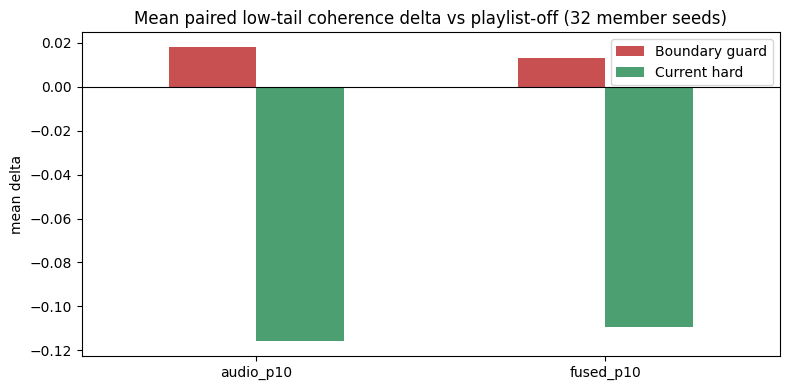

In [7]:
member_summary = summary[(summary["cohort"] == "member") & (summary["metric"].isin(["audio_p10", "fused_p10"]))]
plot = member_summary.pivot(index="metric", columns="treatment", values="mean Δ")
ax = plot.plot(kind="bar", figsize=(8, 4), color=["#c85050", "#4c9f70"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Mean paired low-tail coherence delta vs playlist-off (32 member seeds)")
ax.set_xlabel("")
ax.set_ylabel("mean delta")
ax.legend(title="")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Interpretation

The stress test supports three conclusions:

1. **Remove the current hard behavior.** Compared with playlist-off, current quota/injection loses on member-seed audio p10 for 26/32 seeds and fused p10 for 27/32.
2. **The boundary guard is meaningfully safer.** For audio p10 it produces 6 wins, 25 ties, and 1 loss; mean delta is `+0.018`. Fused p10 produces the same 6/25/1 pattern with mean `+0.013`. Every direct override is locally Pareto-improving by construction.
3. **Playlist evidence should express theme, not manufacture similarity.** A large playlist can legitimately say “this belongs to the same theme,” but cannot make two acoustically remote tracks sound alike. The guard consults that theme only when it can find a candidate that is also objectively better on sound and fused sound/theme.

The one member-seed low-tail regression is the captured seed: the direct `Ancientry → Revival of Darkness` transition improves strongly, but the different second plan favors JoJo/anime context over ultra-smooth generic movie-score transitions. That is a real sound-versus-theme trade-off, not something to hide in a composite score.

## Decision and limitations

**Recommendation:** keep this as the candidate for a Kotlin golden experiment, but do not ship it yet. Before app integration:

- remove companion pool injection, fixed every-third-track quota, and clique membership bonus;
- preserve ordered playlist IDs separately from today's unordered set contract;
- keep the root playlist context fixed across cached plans and never activate it for a nonmember root;
- add the boundary Pareto guard and its limited diversity relaxation;
- log decision provenance, original winner, replacement, gains, root context, and model/index version;
- compare Kotlin pool/scores/IDs to this fixture, then listen to the 8 queues where the guard activates.

This is an **approximate policy-sensitivity replay**, not a causal satisfaction result. Exact historical replay still lacks the engine's long-lived snapshot row order, per-track runtime energy values, a saved scorer/queue timestamp, and decision provenance. Python/ONNX numeric reductions can also differ slightly from Kotlin/Android. The direct vector comparison and paired frozen-input results are trustworthy; exact reproduction of the screenshot's historical queue is not claimed.